## 공간데이터 시각화 기초

많은 분들이 궁금해하시는 부분이 바로 공간 데이터를 시각화하고, 분석 및 응용하는 방법입니다. GeoPandas 패키지를 이용하면 이들을 쉽게 처리할 수 있죠. 물론 QGIS, ArcGIS로도 이러한 역할을 수행할 수 있고, 오히려 더 많은 연산기능을 이용할 수 있습니다. 하지만 Geopandas는 Python 환경에서 실행 가능하다는 강점이 있고, 다른 라이브러리(matplotlib, scikit-learn)와 쉽게 연계할 수 있습니다. 소프트웨어를 바꾸지 않아도 손쉽게 시각화, 회귀분석, 머신러닝 등을 연계할 수 있죠.

<img src="https://user-images.githubusercontent.com/66729377/84263137-359c6800-ab1f-11ea-8e1c-dd5e1a335ca3.png" width="400" height="400" />

<center> 그리고 QGIS는 자주 터진다는 단점이... </center>  


첫 번째 실습은 먼저 Geopandas의 기초적인 내용에 대해 배울 것입니다. Geojson file을 불러오고, 기본적인 시각화와 연산법을 배웁니다.

## 1. Geopandas 패키지 기초

Geopandas는 Python에서 지리정보 데이터 처리의 기하학적 연산과 시각화 등을 돕는 패키지입니다. 여기서 지리정보 데이터라 함은 위치정보를 포함한 정보들을 의미하며 좌표값을 포함합니다 (주로 경위도 좌표). 패키지 이름으로도 알 수 있듯이, GeoPandas는 Pandas와 꽤 비슷해서, 두 가지의 자료형 `GeoSeries`와 `GeoDataFrame`이 존재하고, 각각 Pandas의 `Series`와 `DataFrame` 자료형과 다루는 방법이 비슷합니다. 다만, 지리정보 데이터를 처리하고 분석하는데 몇 가지 속성과 메서드가 추가됩니다.

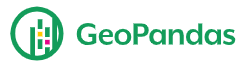

In [101]:
# Import libraries
import matplotlib.pyplot as plt
import koreanize_matplotlib

import numpy as np
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:.6f}')  # 큰 좌표값이 지수(e+06) 표기로 안 나오게 설정

from urllib.request import urlopen
import json


import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import folium

import geopandas as gpd
import mapclassify 


# 좌표계

##  지리좌표계(Geographic Coordinate System, GCS) : 

- 가상의 3차원 타원체 표면상에 위경도 좌표계로 위치 정의
- 전세계를 한번에 나타내야 할 때 많이 쓰이는 좌표계(전지구 좌표계)


### EPSG(European Petroleum Survey Group) 시스템 
- 좌표 참조 시스템(Coordinate Reference System, CRS)에 대한 표준화된 식별자 체계
- 원래는 석유 탐사를 위한 좌표 시스템 표준화 작업에서 시작되었지만, 현재는 전 세계적으로 사용되는 공간 참조 시스템의 표준 코드 체계
- https://epsg.io/4326
- https://www.osgeo.kr/17

### 주요 지리좌표계
#### WGS84 경위도
- GPS가 사용하는 좌표계 
- EPSG:4326
- EPSG:4166

#### Bessel 1841 경위도
- 한국과 일본에 잘 맞는 지역타원체를 사용한 좌표계
- EPSG:4004
- EPSG:4162 

#### GRS80 경위도: WGS84와 거의 유사
- EPSG:4019
- EPSG:4737 

#### Google Mercator: 구글지도/빙지도/야후지도/OSM 등 에서 사용중인 좌표계
- EPSG:3857

##  투영좌표계(Projected Coordinate System, PCS) : 

- 지리좌표계(GCS)를 기반으로 하며, 다음과 같은 요소로 구성

- 기초 타원체(Ellipsoid): 지구의 모양을 수학적으로 표현 (예: GRS80, WGS84)
- 투영법(Projection Method): 지구 표면을 평면에 변환하는 방식
   * 예: UTM(Universal Transverse Mercator), Mercator, Lambert Conformal Conic

- 기준 좌표 (Origin), 중심 경선, 위도 조정 값, 축척 계수
- 단위: 대부분 미터 (m) 사용


#### UTM (Universal Transverse Mercator)
- 전 세계를 6도 간격으로 분할한 구역(Zone) 기반 투영
- 대한민국은 보통 52N 또는 51N 구역 사용
    * 예: EPSG:32652 (WGS84, UTM Zone 52N)

#### TM (Transverse Mercator)
- 국가별 측량 기준점을 중심으로 설정
- 한국 중부는 EPSG:5179 (GRS80 기반 TM 중부원점)

#### KATEC (Korean Authority TM East Central)
- EPSG:5178
- 과거 국토지리정보원에서 사용, 단위: 미터



## KATEC 계열
- 한반도 전체를 하나의 좌표계로 나타낼 때 많이 사용하는 좌표계

#### UTM-K (Bessel)
- 새주소지도에서 사용 중
- EPSG:5178+proj=tmerc +lat_0=38 +lon_0=127.5 +k=0.9996 +x_0=1000000 +y_0=2000000 +ellps=bessel +units=m +no_defs +towgs84=-115.80,474.99,674.11,1.16,-2.31,-1.63,6.43

#### UTM-K (GRS80)
- 네이버지도에서 사용중인 좌표계
- EPSG:5179+proj=tmerc +lat_0=38 +lon_0=127.5 +k=0.9996 +x_0=1000000 +y_0=2000000 +ellps=GRS80 +units=m +no_defs


## 현재 국토지리정보원 표준
- 2002년 이후에 국토지리정보원 지형도에서 사용중인 좌표계입니다.

#### 서부원점(GRS80)
- EPSG:5185+proj=tmerc +lat_0=38 +lon_0=125 +k=1 +x_0=200000 +y_0=600000 +ellps=GRS80 +units=m +no_defs

#### 중부원점(GRS80)
- EPSG:5186+proj=tmerc +lat_0=38 +lon_0=127 +k=1 +x_0=200000 +y_0=600000 +ellps=GRS80 +units=m +no_defs

#### 동부원점(GRS80)
- EPSG:5187+proj=tmerc +lat_0=38 +lon_0=129 +k=1 +x_0=200000 +y_0=600000 +ellps=GRS80 +units=m +no_defs

#### 동해(울릉)원점(GRS80)
- EPSG:5188+proj=tmerc +lat_0=38 +lon_0=131 +k=1 +x_0=200000 +y_0=600000 +ellps=GRS80 +units=m +no_defs

# SGIS(통계지리정보서비스) 행정구역 경계 자료 신청·다운로드 절차

출처: [자료제공 소개](https://sgis.mods.go.kr/view/pss/dataProvdIntrcn), [행정구역경계 지도제공 안내](https://sgis.mods.go.kr/statbd/help4/help01.html) — 통계지리정보서비스(SGIS), 국가데이터처

## 0. 사전 확인

- 사이트: https://sgis.mods.go.kr (구 sgis.kostat.go.kr)
- 제공 좌표계: **UTM-K (GRS80 타원체, EPSG:5179)**
- 행정구역 기준: **행정동 경계 기준**으로만 제공 (법정동 경계는 미제공)
- 지리정보 기준시점: 매년 **6월 30일** 기준
- 통계비밀보호: 인구 5명 미만, 사업체 2개 이하인 경우 통계값 제외 처리됨
- 제공 단위: 시도 / 시군구 / 읍면동 (그 외 집계구·격자 등 분석용 경계는 별도 자료제공 신청 메뉴에서 다룸)

## 1. 회원가입 및 로그인

1. https://sgis.mods.go.kr 접속
2. 우측 상단에서 회원가입 진행 (미가입 시 자료 신청 불가)
3. 가입 후 로그인

## 2. 자료 신청 메뉴 진입

1. 로그인 상태에서 상단 메뉴 중 **자료제공** 메뉴로 이동
   - 또는 신청 폼 URL: https://sgis.mods.go.kr/view/pss/requestData
2. **자료신청 1단계**: 이용약관 동의 및 신청자 정보 입력

## 3. 자료 선택 및 신청 완료

1. 필요한 행정구역 단위 선택 (시도 / 시군구 / 읍면동 등)
2. 필요한 연도(기준년도) 선택
3. 신청 사유 등 필요 항목 입력 후 신청 완료 제출

## 4. 승인 대기

- 신청 후 관리자 승인을 거쳐야 다운로드가 가능
- 승인 여부는 마이페이지 또는 알림(이메일 등)으로 확인

## 5. 다운로드

1. 승인 완료 후 **자료다운로드** 화면으로 이동
2. 신청한 항목 목록에서 파일 다운로드 (Shapefile(.shp) 등 공간정보 형식 제공)
3. 압축 해제 후 QGIS, Python(geopandas), R, ArcGIS 등에서 활용

## 6. 참고

- 다운로드 받은 zip 안의 **코드집·자료 이용안내** 문서를 함께 확인하고 사용할 것 (행정동 코드 체계, 필드 설명 등)
- 좌표계가 EPSG:5179(UTM-K)이므로, 위경도(EPSG:4326) 기반 데이터와 결합할 때는 `geopandas`의 `.to_crs(epsg=4326)` 등으로 변환 필요

In [102]:
# SGIS에서 2025년 2분기 행정동 경계를 다운로드받음 (bnd_all_00_2025_2Q
# 읍면동 행정경계 Shapefile 불러오기 (SGIS, 좌표계: EPSG:5179)
dong_5179 = gpd.read_file('bnd_all_00_2025_2Q/bnd_dong_00_2025_2Q.shp')
print(type(dong_5179))
print(dong_5179.crs)
dong_5179

<class 'geopandas.geodataframe.GeoDataFrame'>
EPSG:5179


,BASE_DATE,ADM_CD,ADM_NM,geometry
0,20250630,11010530,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1..."
1,20250630,11010540,삼청동,"POLYGON ((953844.082 1955492.177, 953858.644 1..."
2,20250630,11010550,부암동,"POLYGON ((952490.38 1956548.821, 952497.594 19..."
3,20250630,11010560,평창동,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
4,20250630,11010570,무악동,"POLYGON ((952298.144 1953539.606, 952324.838 1..."
...,...,...,...,...
3554,20250630,39020580,서홍동,"POLYGON ((909727.287 1481146.108, 909749.535 1..."
3555,20250630,39020590,대륜동,"MULTIPOLYGON (((908207.178 1469892.602, 908205..."
3556,20250630,39020600,대천동,"MULTIPOLYGON (((907092.035 1470884.232, 907090..."
3557,20250630,39020610,중문동,"POLYGON ((903768.768 1485860.389, 903877.661 1..."


In [111]:
# Ellipsoid: GRS 1980
# Datum: Korean Geodetic Datum 2002
# method: Transverse Mercator
# unit : meter
dong_5179.crs

<Projected CRS: EPSG:5179>
Name: KGD2002 / Unified CS
Axis Info [cartesian]:
- X[north]: Northing (metre)
- Y[east]: Easting (metre)
Area of Use:
- name: Republic of Korea (South Korea) - onshore and offshore.
- bounds: (122.71, 28.6, 134.28, 40.27)
Coordinate Operation:
- name: Korea Unified Belt
- method: Transverse Mercator
Datum: Korean Geodetic Datum 2002
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [103]:
# ADM_CD가 '11'로 시작하는 서울 지역만 추출
# 426개 읍면동으로 정상 필터링되는 것을 확인 (서울시 읍면동 수와 일치).
dong_seoul_5179 = dong_5179[dong_5179['ADM_CD'].str.startswith('11')].reset_index(drop=True)
print(len(dong_seoul_5179))
dong_seoul_5179

426


,BASE_DATE,ADM_CD,ADM_NM,geometry
0,20250630,11010530,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1..."
1,20250630,11010540,삼청동,"POLYGON ((953844.082 1955492.177, 953858.644 1..."
2,20250630,11010550,부암동,"POLYGON ((952490.38 1956548.821, 952497.594 19..."
3,20250630,11010560,평창동,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
4,20250630,11010570,무악동,"POLYGON ((952298.144 1953539.606, 952324.838 1..."
...,...,...,...,...
421,20250630,11250730,천호2동,"POLYGON ((966110.271 1950148.101, 966118.161 1..."
422,20250630,11250740,길동,"POLYGON ((968944.218 1949625.263, 968943.832 1..."
423,20250630,11250750,강일동,"POLYGON ((971452.641 1953347.663, 971446.624 1..."
424,20250630,11250760,상일1동,"POLYGON ((971190.564 1949669.365, 971193.744 1..."


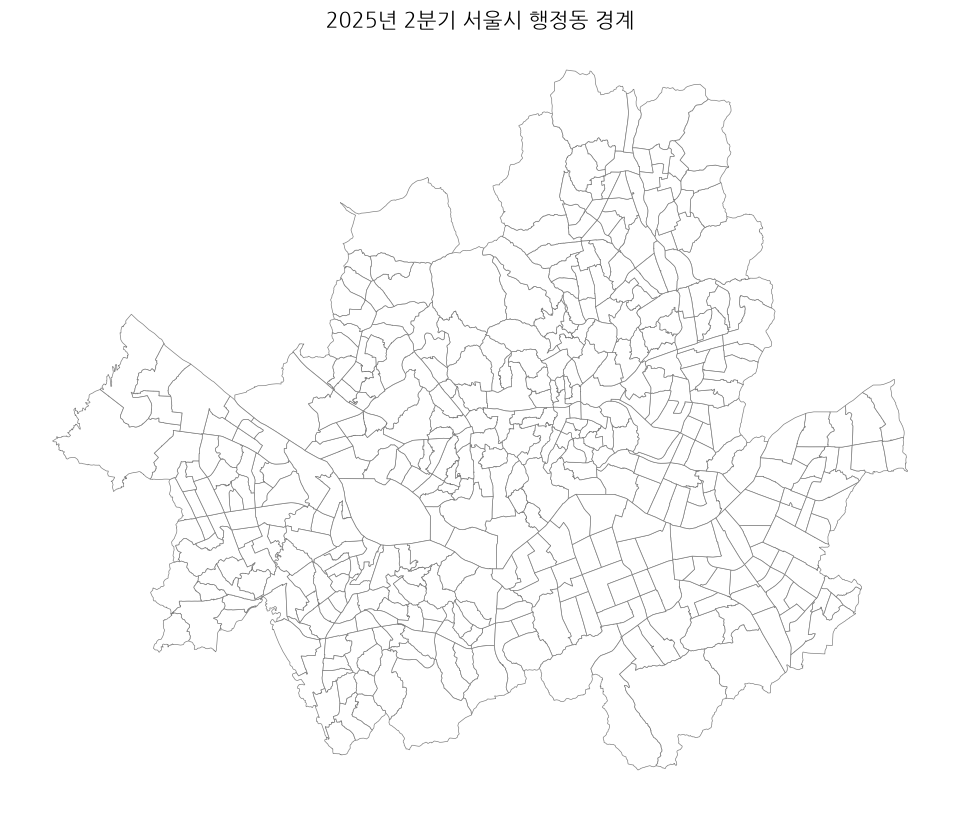

<Figure size 640x480 with 0 Axes>

In [114]:
# matplotlib으로 행정동 경계 표현
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(1,1,1)
dong_seoul_5179.plot(ax = ax,  color = 'white', edgecolor='grey', linewidth=0.5)

plt.title('2025년 2분기 서울시 행정동 경계', fontsize = 15)
plt.grid(False) 
plt.axis(False)
plt.show()
plt.savefig('image/1_1.png')  # 그래프 출력과 저장

In [108]:
# 지오코딩한 2026년 서울시 아파트 실거래가 데이터 불러오기 
seoul_apt_price_2026_geocoded=pd.read_csv('data/seoul_apt_price_2026_geocoded.csv', encoding='utf-8-sig')
seoul_apt_price_2026_geocoded

,RCPT_YR,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,LOTNO_SE_NM,MNO,SNO,BLDG_NM,...,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE,OPBIZ_RESTAGNT_SGG_NM,LAT,LON,PRICE_PER_SQM,PRICE_PER_PYEONG
0,2026,11530,구로구,11000,온수동,1,대지,154,0,리치안풍산,...,NaN,NaN,2009,아파트,중개거래,서울 구로구,37.495866,126.817576,553.000000,1828.100000
1,2026,11260,중랑구,10500,망우동,1,대지,479,0,한일써너스빌리젠시1단지(101동),...,NaN,NaN,2008,아파트,중개거래,서울 중랑구,37.597335,127.093478,1044.400000,3452.500000
2,2026,11740,강동구,10900,천호동,1,대지,19,1,우성,...,NaN,NaN,1985,아파트,직거래,NaN,37.549768,127.138816,1298.700000,4293.300000
3,2026,11305,강북구,10100,미아동,1,대지,194,2,엘리프미아역1단지,...,분양권,NaN,0,아파트,중개거래,서울 강북구,37.629276,127.025459,1400.100000,4628.300000
4,2026,11650,서초구,10100,방배동,1,대지,866,20,방배대우디오빌,...,NaN,NaN,2005,아파트,중개거래,서울 동작구,37.486044,126.984201,1006.800000,3328.100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49954,2026,11470,양천구,10300,신월동,1,대지,1026,0,양천벽산블루밍1단지,...,NaN,NaN,2006,아파트,중개거래,서울 양천구,37.524360,126.839446,1046.800000,3460.600000
49955,2026,11380,은평구,10600,대조동,1,대지,9,19,모아아파트(103동),...,NaN,NaN,2015,아파트,중개거래,서울 은평구,37.610228,126.927766,980.900000,3242.800000
49956,2026,11680,강남구,11500,수서동,1,대지,746,0,까치마을,...,NaN,20260309.000000,1993,아파트,중개거래,서울 강남구,37.484734,127.087618,4094.100000,13534.100000
49957,2026,11260,중랑구,10600,신내동,1,대지,397,0,동성1,...,NaN,NaN,1993,아파트,중개거래,서울 중랑구,37.609116,127.097679,830.000000,2743.700000


In [109]:
# 지오코딩한 2026년 서울시 아파트 실거래가 데이터 GeoDataFrame으로 변환 (좌표계: EPSG:4326, WGS84)
# geometry 컬럼 생성 확인
seoul_apt_price_2026_gdf = gpd.GeoDataFrame(
    seoul_apt_price_2026_geocoded,
    geometry=gpd.points_from_xy(seoul_apt_price_2026_geocoded['LON'], seoul_apt_price_2026_geocoded['LAT']),
    crs='epsg:4326',
)

print(type(seoul_apt_price_2026_gdf))
print(seoul_apt_price_2026_gdf.crs)
seoul_apt_price_2026_gdf

<class 'geopandas.geodataframe.GeoDataFrame'>
epsg:4326


,RCPT_YR,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,LOTNO_SE_NM,MNO,SNO,BLDG_NM,...,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE,OPBIZ_RESTAGNT_SGG_NM,LAT,LON,PRICE_PER_SQM,PRICE_PER_PYEONG,geometry
0,2026,11530,구로구,11000,온수동,1,대지,154,0,리치안풍산,...,NaN,2009,아파트,중개거래,서울 구로구,37.495866,126.817576,553.000000,1828.100000,POINT (126.81758 37.49587)
1,2026,11260,중랑구,10500,망우동,1,대지,479,0,한일써너스빌리젠시1단지(101동),...,NaN,2008,아파트,중개거래,서울 중랑구,37.597335,127.093478,1044.400000,3452.500000,POINT (127.09348 37.59734)
2,2026,11740,강동구,10900,천호동,1,대지,19,1,우성,...,NaN,1985,아파트,직거래,NaN,37.549768,127.138816,1298.700000,4293.300000,POINT (127.13882 37.54977)
3,2026,11305,강북구,10100,미아동,1,대지,194,2,엘리프미아역1단지,...,NaN,0,아파트,중개거래,서울 강북구,37.629276,127.025459,1400.100000,4628.300000,POINT (127.02546 37.62928)
4,2026,11650,서초구,10100,방배동,1,대지,866,20,방배대우디오빌,...,NaN,2005,아파트,중개거래,서울 동작구,37.486044,126.984201,1006.800000,3328.100000,POINT (126.9842 37.48604)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49954,2026,11470,양천구,10300,신월동,1,대지,1026,0,양천벽산블루밍1단지,...,NaN,2006,아파트,중개거래,서울 양천구,37.524360,126.839446,1046.800000,3460.600000,POINT (126.83945 37.52436)
49955,2026,11380,은평구,10600,대조동,1,대지,9,19,모아아파트(103동),...,NaN,2015,아파트,중개거래,서울 은평구,37.610228,126.927766,980.900000,3242.800000,POINT (126.92777 37.61023)
49956,2026,11680,강남구,11500,수서동,1,대지,746,0,까치마을,...,20260309.000000,1993,아파트,중개거래,서울 강남구,37.484734,127.087618,4094.100000,13534.100000,POINT (127.08762 37.48473)
49957,2026,11260,중랑구,10600,신내동,1,대지,397,0,동성1,...,NaN,1993,아파트,중개거래,서울 중랑구,37.609116,127.097679,830.000000,2743.700000,POINT (127.09768 37.60912)


In [112]:
# Ellipsoid: WGS 84
# Datum: World Geodetic System 1984 ensemble
# unit : degree
seoul_apt_price_2026_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

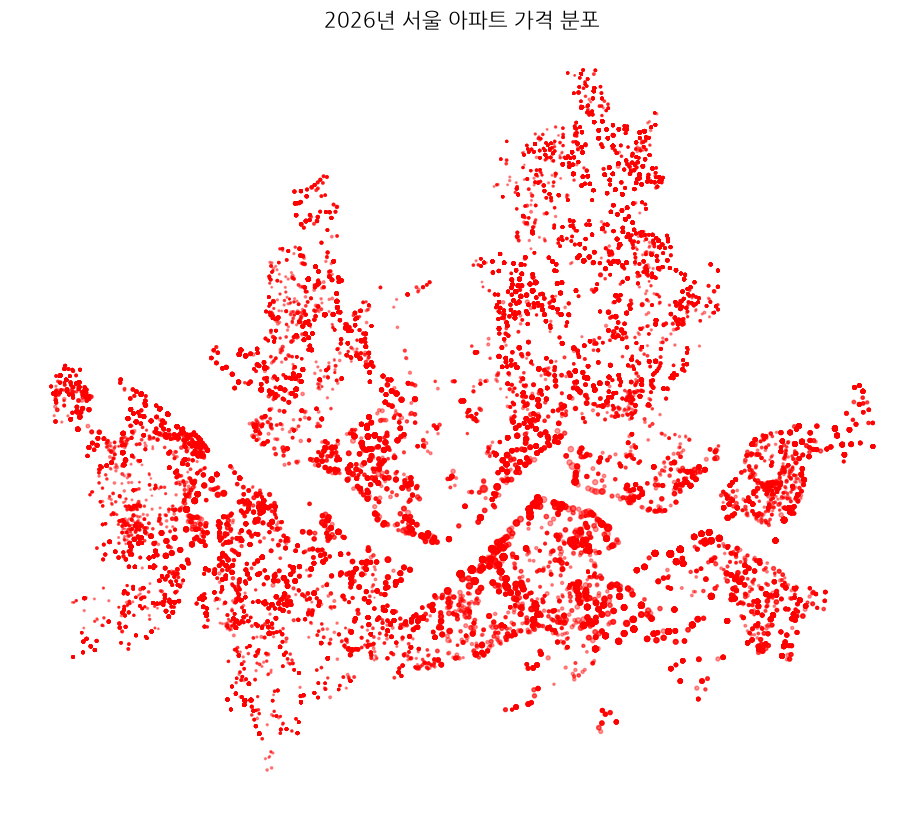

<Figure size 640x480 with 0 Axes>

In [115]:
# matplotlib으로 아파트 가격 분포 표현
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(1,1,1)

seoul_apt_price_2026_gdf.plot(
    ax=ax,
    markersize=seoul_apt_price_2026_gdf["PRICE_PER_PYEONG"] / 1000,
    color="red",
    alpha=0.4
)

plt.title('2026년 서울 아파트 가격 분포', fontsize = 15)
plt.grid(False) 
plt.axis(False)
plt.show()
plt.savefig('image/1_2.png')

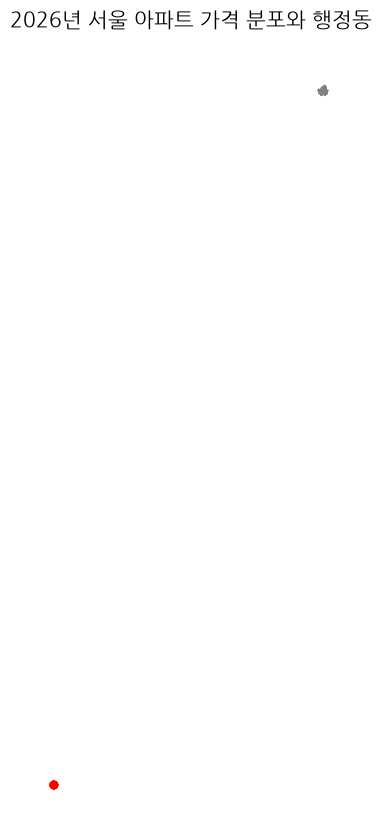

<Figure size 640x480 with 0 Axes>

In [117]:
# 아파트 가격 분포(CRS=4326)와 행정동 경계(CRS=5179) 함께 시각화
# 두 레이어가 CRS가 달라서 바로 시각화하면 정렬이 되지 않습니다. 
# CRS가 다른 두 GeoDataFrame을 시각화하기 위해서는 좌표계를 맞춰야 함.

fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(1,1,1)
dong_seoul_5179.plot(ax = ax,  color = 'white', edgecolor='grey', linewidth=0.5)

seoul_apt_price_2026_gdf.plot(
    ax=ax,
    markersize=seoul_apt_price_2026_gdf["PRICE_PER_PYEONG"] / 1000,
    color="red",
    alpha=0.4
)

plt.title('2026년 서울 아파트 가격 분포와 행정동', fontsize = 15)
plt.grid(False) 
plt.axis(False)
plt.show()
plt.savefig('image/1_3.png')

In [119]:
# CRS 변환: EPSG:5179 -> EPSG:4326
dong_seoul_4326 = dong_seoul_5179.to_crs(epsg=4326)

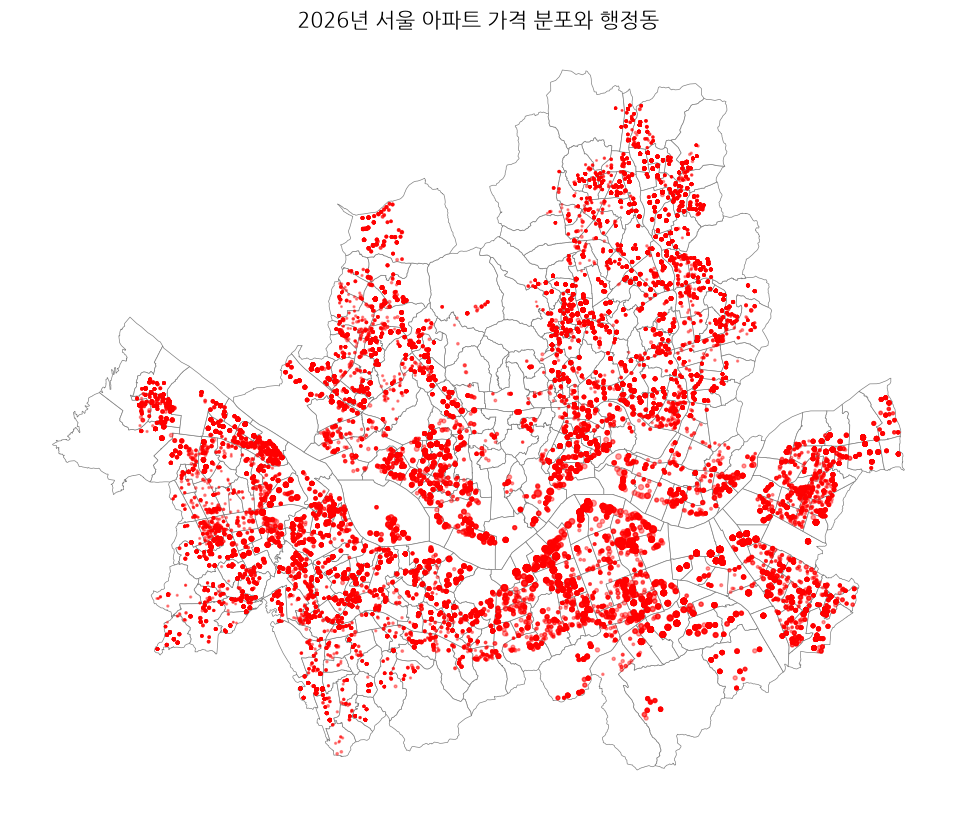

<Figure size 640x480 with 0 Axes>

In [120]:
# 아파트 가격 분포(CRS=4326)와 행정동 경계(CRS=4326) 함께 시각화
# CRS가 같은 두 GeoDataFrame을 시각화할 수 있음.

fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(1,1,1)
dong_seoul_4326.plot(ax = ax,  color = 'white', edgecolor='grey', linewidth=0.5)

seoul_apt_price_2026_gdf.plot(
    ax=ax,
    markersize=seoul_apt_price_2026_gdf["PRICE_PER_PYEONG"] / 1000,
    color="red",
    alpha=0.4
)

plt.title('2026년 서울 아파트 가격 분포와 행정동', fontsize = 15)
plt.grid(False) 
plt.axis(False)
plt.show()
plt.savefig('image/1_4.png')

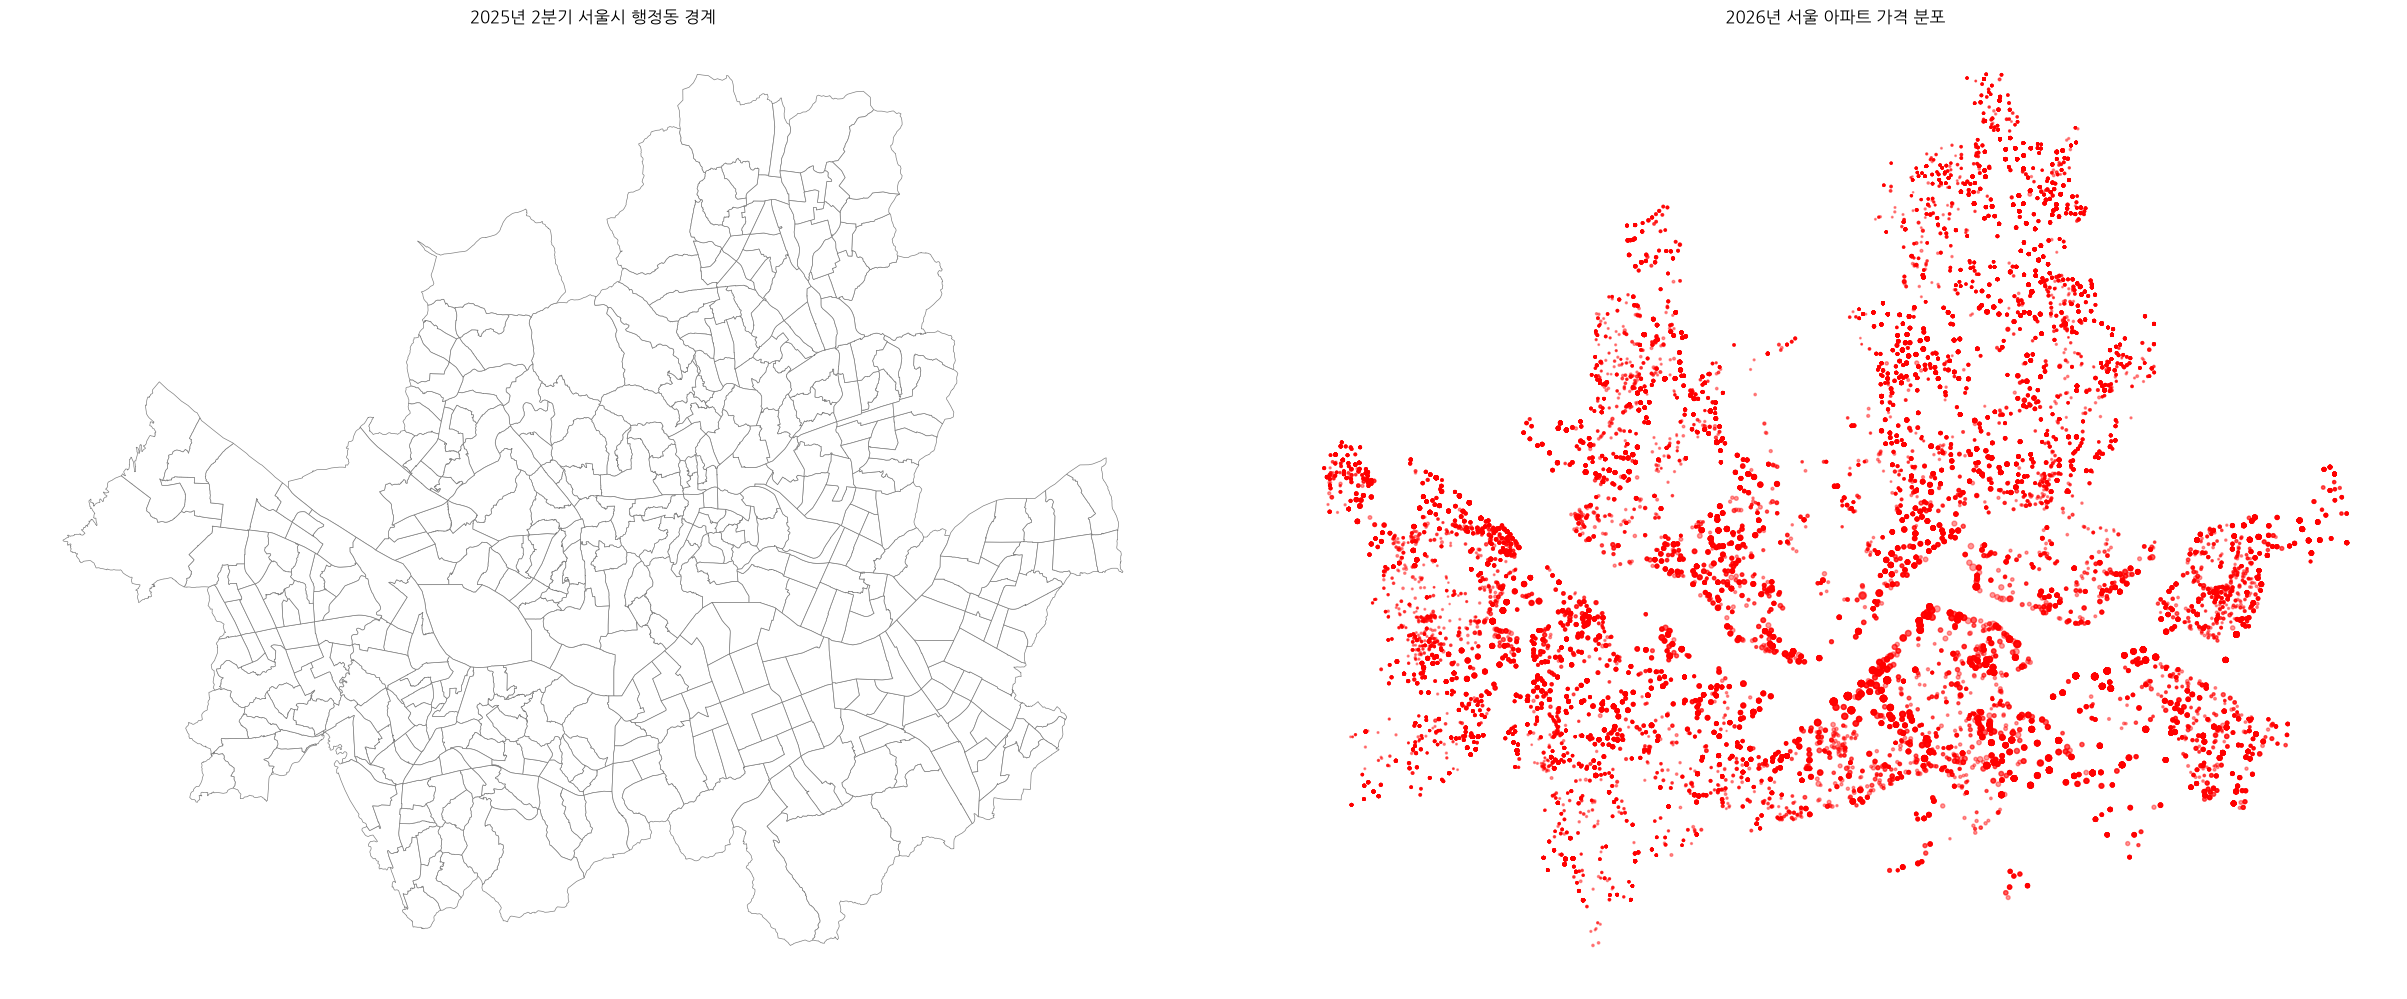

<Figure size 640x480 with 0 Axes>

In [121]:
# Subplot : 병렬적으로 배치

fig = plt.figure(figsize = (25,10))
ax1 = fig.add_subplot(1,2,1) # 1행 2열의 첫 번째 subplot
ax2 = fig.add_subplot(1,2,2) # 1행 2열의 두 번째 subplot

# print subplot #1
ax1.set_title("2025년 2분기 서울시 행정동 경계")
ax1.set_axis_off()
dong_seoul_4326.plot(ax = ax1,  color = 'white', edgecolor='grey', linewidth=0.5)

# print subplot #2
ax2.set_title("2026년 서울 아파트 가격 분포")
ax2.set_axis_off()
seoul_apt_price_2026_gdf.plot(
    ax=ax2,
    markersize=seoul_apt_price_2026_gdf["PRICE_PER_PYEONG"] / 1000,
    color="red",
    alpha=0.4
)

plt.tight_layout()
plt.show()
plt.savefig('image/1_5.png')

## 2 Geopandas 연산

Geopandas에서도 GIS와 마찬가지로 기본적인 연산을 제공합니다. 먼저 기본적인 면적, 길이, 중심점 등이 있겠죠?\
Polygon 형태의 Geometry를 가진 데이터들은 다음과 같은 속성들을 가질 수 있습니다.

  - `area` : 넓이 
  - `boundary` : 테두리          : polygon을 Multiline 형태로 변환
  - `centroid` : 중앙지점        : polygon을 Point 형태로 변환
  
이번에는 하나의 GeoDataFrame 객체 안에서 기본적인 속성과 관련한 연산들을 수행해보도록 하겠습니다.

### 속성 연산

area 함수를 사용하실 때 주의하실 점은, 이 넓이는 좌표계를 기준으로 계산한 넓이이며, 흔히 사용하는 제곱미터, 킬로미터, 마일과 같은 단위가 아닙니다!!\
따라서 경위도 좌표계에서는 면적 비만 계산할 수 있으며, 만약 ㎡ 단위로 넓이를 계산하고 싶을 경우, 경위도가 아닌 미터를 단위로 하는 좌표계로 변환 후 넓이를 계산하여야 합니다.

In [122]:
# 면적, 거리를 계산하기 위해 PCS 좌표계(EPSG:5179) 사용
dong_seoul_5179

,BASE_DATE,ADM_CD,ADM_NM,geometry
0,20250630,11010530,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1..."
1,20250630,11010540,삼청동,"POLYGON ((953844.082 1955492.177, 953858.644 1..."
2,20250630,11010550,부암동,"POLYGON ((952490.38 1956548.821, 952497.594 19..."
3,20250630,11010560,평창동,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
4,20250630,11010570,무악동,"POLYGON ((952298.144 1953539.606, 952324.838 1..."
...,...,...,...,...
421,20250630,11250730,천호2동,"POLYGON ((966110.271 1950148.101, 966118.161 1..."
422,20250630,11250740,길동,"POLYGON ((968944.218 1949625.263, 968943.832 1..."
423,20250630,11250750,강일동,"POLYGON ((971452.641 1953347.663, 971446.624 1..."
424,20250630,11250760,상일1동,"POLYGON ((971190.564 1949669.365, 971193.744 1..."


In [124]:
# 면적계산
dong_seoul_5179['SQM'] = dong_seoul_5179.area            # 제곱미터 단위 면적

dong_seoul_5179['HA'] = dong_seoul_5179.area / 10000    # 헥타르 단위 면적

dong_seoul_5179

,BASE_DATE,ADM_CD,ADM_NM,geometry,SQM,HA
0,20250630,11010530,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1...",1157671.317613,115.767132
1,20250630,11010540,삼청동,"POLYGON ((953844.082 1955492.177, 953858.644 1...",1477187.668374,147.718767
2,20250630,11010550,부암동,"POLYGON ((952490.38 1956548.821, 952497.594 19...",2273287.068848,227.328707
3,20250630,11010560,평창동,"POLYGON ((953683.828 1959209.871, 953665.283 1...",8940412.645357,894.041265
4,20250630,11010570,무악동,"POLYGON ((952298.144 1953539.606, 952324.838 1...",369245.482269,36.924548
...,...,...,...,...,...,...
421,20250630,11250730,천호2동,"POLYGON ((966110.271 1950148.101, 966118.161 1...",1849736.814033,184.973681
422,20250630,11250740,길동,"POLYGON ((968944.218 1949625.263, 968943.832 1...",1630343.882755,163.034388
423,20250630,11250750,강일동,"POLYGON ((971452.641 1953347.663, 971446.624 1...",2270383.713701,227.038371
424,20250630,11250760,상일1동,"POLYGON ((971190.564 1949669.365, 971193.744 1...",1802631.934717,180.263193


그리고 Geometry 간 거리를 계산 해주는 함수 또한 유용하게 사용됩니다. 
- `distance` : 두 점사이의 거리

마찬가지로 좌표계에 따른 거리이기 때문에 주의하셔야 합니다!

In [127]:
# 사직동 중심점
sajik=dong_seoul_5179.loc[dong_seoul_5179['ADM_NM'] == '사직동','geometry'].squeeze().centroid
print(sajik)

# 길동 중심점
gil=dong_seoul_5179.loc[dong_seoul_5179['ADM_NM'] == '길동','geometry'].squeeze().centroid
print(gil)


POINT (953232.513802938 1952855.5514093295)
POINT (968723.46165303 1948989.2130791654)


In [128]:
# 사직동-길동 거리 (미터)
sajik.distance(gil)

15966.15286716136

In [129]:
# 5179 좌표계 중심점 추출
dong_seoul_5179["x_cor"] = dong_seoul_5179["geometry"].centroid.x
dong_seoul_5179["y_cor"] = dong_seoul_5179["geometry"].centroid.y

# 4326 위경도 중심점
dong_seoul_5179["lon"] = dong_seoul_5179["geometry"].to_crs(epsg=4326).centroid.x
dong_seoul_5179["lat"] = dong_seoul_5179["geometry"].to_crs(epsg=4326).centroid.y

dong_seoul_5179

C:\Users\leeja\AppData\Local\Temp\ipykernel_46516\2375045704.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  dong_seoul_5179["lon"] = dong_seoul_5179["geometry"].to_crs(epsg=4326).centroid.x
C:\Users\leeja\AppData\Local\Temp\ipykernel_46516\2375045704.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  dong_seoul_5179["lat"] = dong_seoul_5179["geometry"].to_crs(epsg=4326).centroid.y


,BASE_DATE,ADM_CD,ADM_NM,geometry,SQM,HA,x_cor,y_cor,lon,lat
0,20250630,11010530,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1...",1157671.317613,115.767132,953232.513803,1952855.551409,126.970376,37.573888
1,20250630,11010540,삼청동,"POLYGON ((953844.082 1955492.177, 953858.644 1...",1477187.668374,147.718767,954197.657771,1954456.176976,126.981206,37.588364
2,20250630,11010550,부암동,"POLYGON ((952490.38 1956548.821, 952497.594 19...",2273287.068848,227.328707,952643.859960,1955418.819374,126.963544,37.596962
3,20250630,11010560,평창동,"POLYGON ((953683.828 1959209.871, 953665.283 1...",8940412.645357,894.041265,953060.038748,1957493.974614,126.968125,37.615687
4,20250630,11010570,무악동,"POLYGON ((952298.144 1953539.606, 952324.838 1...",369245.482269,36.924548,952193.444170,1953218.986565,126.958586,37.577111
...,...,...,...,...,...,...,...,...,...,...
421,20250630,11250730,천호2동,"POLYGON ((966110.271 1950148.101, 966118.161 1...",1849736.814033,184.973681,966609.348800,1949585.037048,127.122009,37.544992
422,20250630,11250740,길동,"POLYGON ((968944.218 1949625.263, 968943.832 1...",1630343.882755,163.034388,968723.461653,1948989.213079,127.145967,37.539696
423,20250630,11250750,강일동,"POLYGON ((971452.641 1953347.663, 971446.624 1...",2270383.713701,227.038371,971154.465911,1952225.006339,127.173356,37.568942
424,20250630,11250760,상일1동,"POLYGON ((971190.564 1949669.365, 971193.744 1...",1802631.934717,180.263193,970390.505290,1950197.083880,127.164787,37.550638


In [130]:
dong_seoul_4326['centroid']=dong_seoul_4326.centroid
dong_seoul_4326

C:\Users\leeja\AppData\Local\Temp\ipykernel_46516\3216021880.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  dong_seoul_4326['centroid']=dong_seoul_4326.centroid


,BASE_DATE,ADM_CD,ADM_NM,geometry,centroid
0,20250630,11010530,사직동,"POLYGON ((126.97399 37.57823, 126.974 37.57809...",POINT (126.97038 37.57389)
1,20250630,11010540,삼청동,"POLYGON ((126.97714 37.59768, 126.9773 37.5976...",POINT (126.98121 37.58836)
2,20250630,11010550,부암동,"POLYGON ((126.96173 37.60714, 126.96182 37.607...",POINT (126.96354 37.59696)
3,20250630,11010560,평창동,"POLYGON ((126.97508 37.63118, 126.97488 37.630...",POINT (126.96813 37.61569)
4,20250630,11010570,무악동,"POLYGON ((126.95975 37.58001, 126.96006 37.579...",POINT (126.95859 37.57711)
...,...,...,...,...,...
421,20250630,11250730,천호2동,"POLYGON ((127.11633 37.55005, 127.11642 37.550...",POINT (127.12201 37.54499)
422,20250630,11250740,길동,"POLYGON ((127.14844 37.54544, 127.14843 37.545...",POINT (127.14597 37.5397)
423,20250630,11250750,강일동,"POLYGON ((127.17669 37.57907, 127.17662 37.579...",POINT (127.17336 37.56894)
424,20250630,11250760,상일1동,"POLYGON ((127.17387 37.54591, 127.1739 37.5457...",POINT (127.16479 37.55064)


In [131]:
# 행정구역 중심점 GeoDataFrame을 생성해보도록 하겠습니다.
# 기존의 폴리곤 geometry 컬럼을 제거하고, 중심점 좌표를 geometry 컬럼으로 설정하여 GeoDataFrame을 생성합니다.

dong_centroid_df = pd.DataFrame(data=dong_seoul_4326.drop(columns='geometry'))
dong_centroid_df = gpd.GeoDataFrame(dong_centroid_df,geometry=dong_centroid_df.centroid)


dong_centroid_df

,BASE_DATE,ADM_CD,ADM_NM,centroid,geometry
0,20250630,11010530,사직동,POINT (126.97038 37.57389),POINT (126.97038 37.57389)
1,20250630,11010540,삼청동,POINT (126.98121 37.58836),POINT (126.98121 37.58836)
2,20250630,11010550,부암동,POINT (126.96354 37.59696),POINT (126.96354 37.59696)
3,20250630,11010560,평창동,POINT (126.96813 37.61569),POINT (126.96813 37.61569)
4,20250630,11010570,무악동,POINT (126.95859 37.57711),POINT (126.95859 37.57711)
...,...,...,...,...,...
421,20250630,11250730,천호2동,POINT (127.12201 37.54499),POINT (127.12201 37.54499)
422,20250630,11250740,길동,POINT (127.14597 37.5397),POINT (127.14597 37.5397)
423,20250630,11250750,강일동,POINT (127.17336 37.56894),POINT (127.17336 37.56894)
424,20250630,11250760,상일1동,POINT (127.16479 37.55064),POINT (127.16479 37.55064)


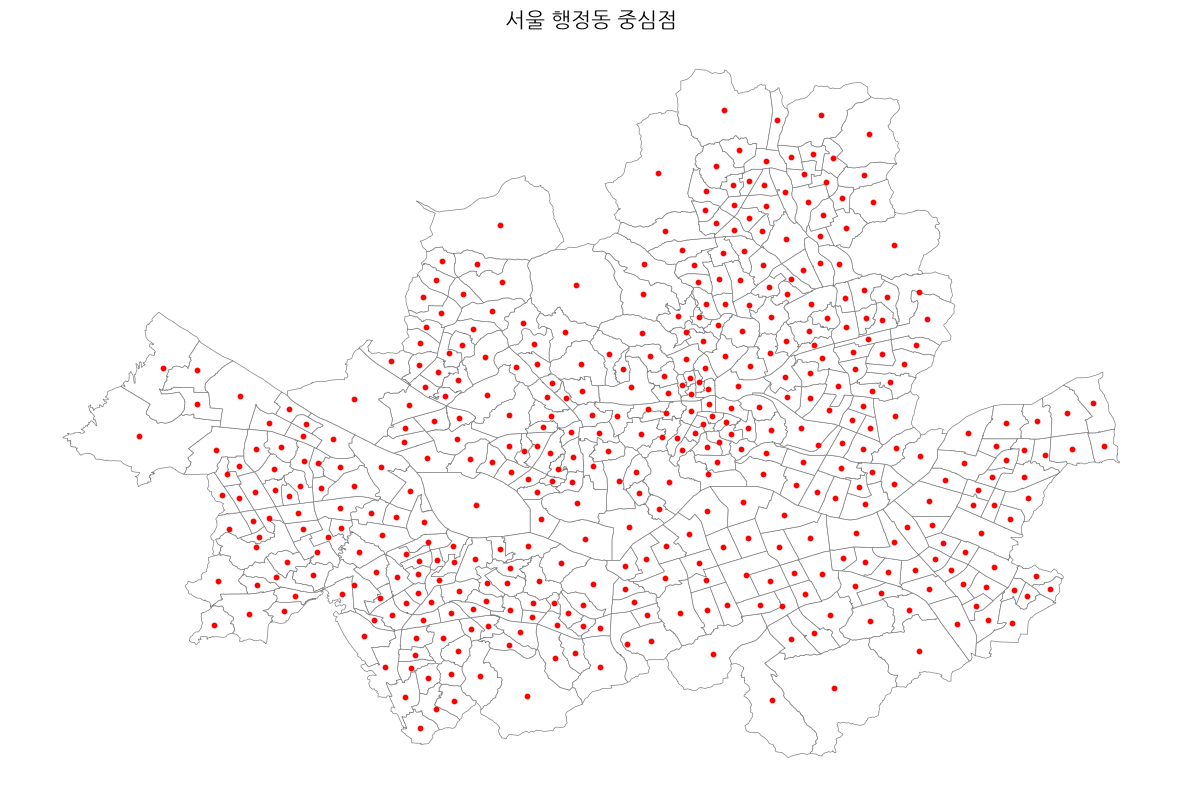

<Figure size 640x480 with 0 Axes>

In [133]:
# matplotlib 으로 간단히 표현
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(1,1,1)
dong_seoul_4326.plot(ax = ax,  color = 'white', edgecolor='grey', linewidth=0.5)
dong_centroid_df.plot(ax=ax, markersize=10, color='red')

plt.title('서울 행정동 중심점', fontsize = 15)
plt.grid(False) 
plt.axis(False)
plt.show()
plt.savefig('image/1_6.png')

### 도형변환연산

이번에는 GeoDataFrame의 도형들을 변환하는 연산을 수행하겠습니다.

* `envelope` 
 - 각 Polygon들을 감싸는 가장 작은 사각형을 그린다. 

* `buffer`(distance, resolution=16)
 - Point, Line에서부터 주어진 거리 내의 지점들을 이어 Polygon을 만든다.
 - Polygon에 적용할 경우 경계부에서 주어진 거리만큼 확장한다. 

* `unary_union`
 - 여러 개 도형(geometry)의 합집합을 구하여, 하나의 객체로 만든다.
 
* `dissolve`
 - GeoDataFrame의 도형들을 지정한 그룹별로 unary_union 연산을 수행하여 합친다.

마찬가지로 buffer distance 역시 km, m단위가 아닌 좌표계(도) 단위이므로, 사용 시 미터단위의 좌표계로 변환하시는 걸 추천드립니다.

C:\Users\leeja\AppData\Local\Temp\ipykernel_46516\1974874453.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gpd.GeoSeries([dong_seoul_5179.unary_union]).plot(ax=ax3, color='gray', edgecolor='black', alpha=0.2, linewidth=1)


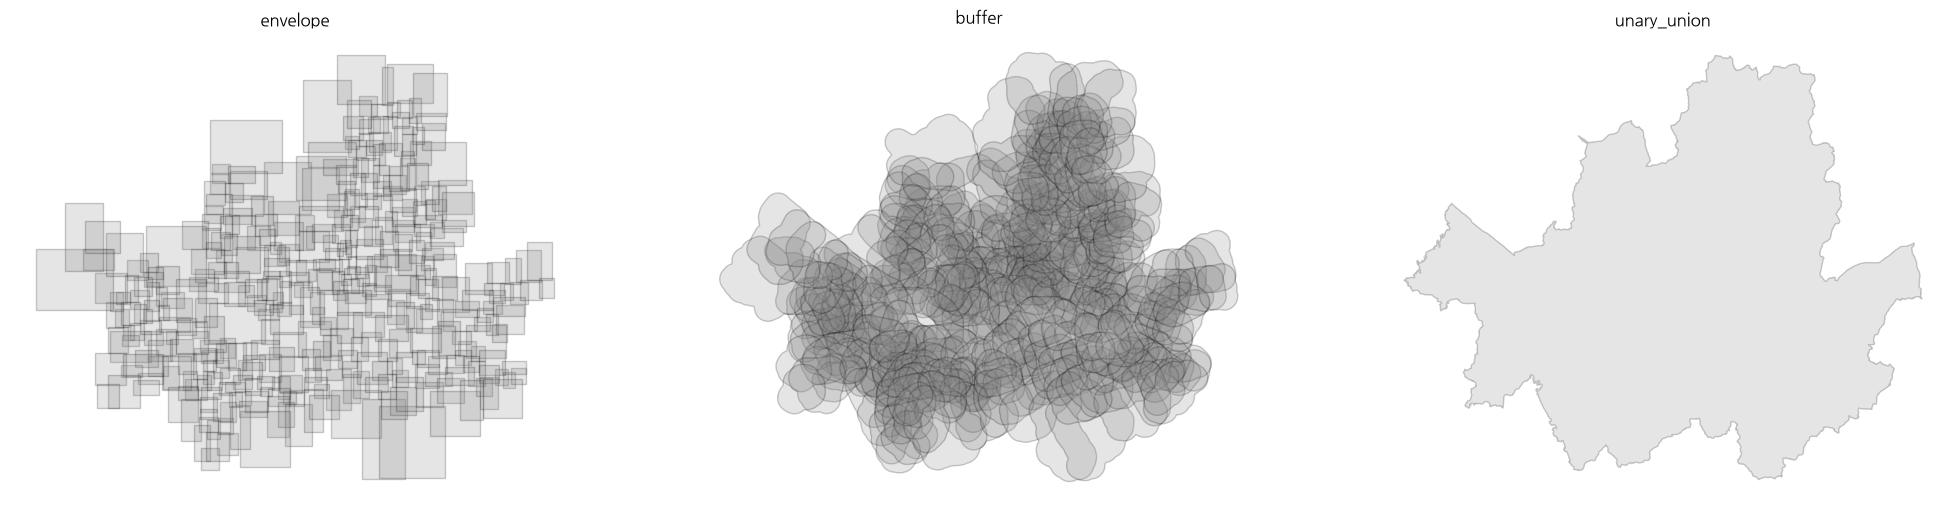

<Figure size 640x480 with 0 Axes>

In [134]:
# 행정동 ploygon에 3개의 도형 변환 연산을 수행해보겠습니다 : envelop, buffer, unary_union
fig = plt.figure(figsize = (25,10))
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)


ax1.set_title("envelope")
ax1.set_axis_off()
dong_seoul_5179.envelope.plot(ax=ax1, color='gray', edgecolor='black', alpha=0.2, linewidth=1)

ax2.set_title("buffer")
ax2.set_axis_off()
dong_seoul_5179.geometry.buffer(1000).plot(ax=ax2, color='gray', edgecolor='black', alpha=0.2, linewidth=1)

ax3.set_title("unary_union")
ax3.set_axis_off()
gpd.GeoSeries([dong_seoul_5179.unary_union]).plot(ax=ax3, color='gray', edgecolor='black', alpha=0.2, linewidth=1)

plt.show()
plt.savefig('image/1_7.png')

### 관계연산

다음은 2개 이상의 GeoDataFrame 객체들 간 관계에 관련한 연산들을 수행하는 법을 배웁니다.

#### overlay 연산

먼저 overlay 연산은 두 개 GeoDataFrame들의 도형(geometry)을 겹쳐 공간적 특성이 복합된 새로운 GeoDataFrame을 생성합니다.\
4개의 연산(intersection, union, symetrical difference, Difference 4가지 Type이 있으며, 연산은 다음과 같습니다.

<img src="http://docs.qgis.org/testing/en/_images/overlay_operations.png" width="900" height="300" />


### Intersection 연산
여기서는 가장 많이 다루는 intersection 연산에 대해 살펴보겠습니다. 이 연산을 이용하면 원하는 지역의 데이터 만을 추출할 수 있습니다.

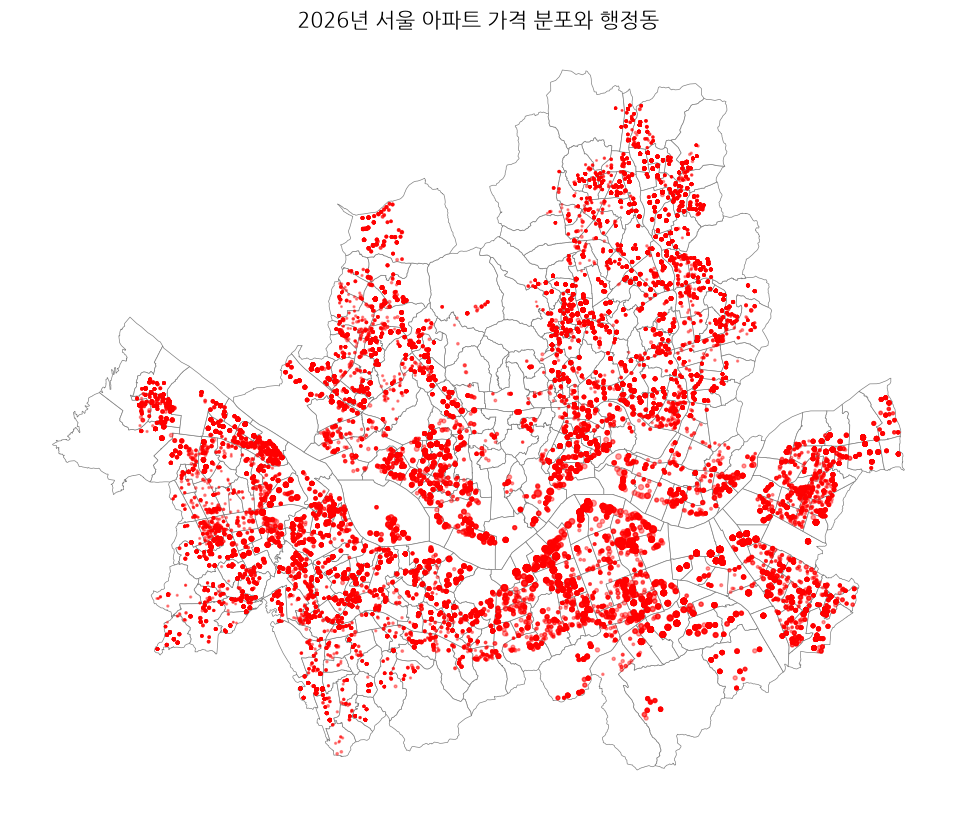

In [137]:
# 아파트 가격 분포(CRS=4326)와 행정동 경계(CRS=4326) 함께 시각화
# CRS가 같은 두 GeoDataFrame을 시각화할 수 있음.

fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(1,1,1)
dong_seoul_4326.plot(ax = ax,  color = 'white', edgecolor='grey', linewidth=0.5)

seoul_apt_price_2026_gdf.plot(
    ax=ax,
    markersize=seoul_apt_price_2026_gdf["PRICE_PER_PYEONG"] / 1000,
    color="red",
    alpha=0.4
)

plt.title('2026년 서울 아파트 가격 분포와 행정동', fontsize = 15)
plt.grid(False) 
plt.axis(False)
plt.show()


In [138]:
dong_seoul_4326.head()

,BASE_DATE,ADM_CD,ADM_NM,geometry,centroid
0,20250630,11010530,사직동,"POLYGON ((126.97399 37.57823, 126.974 37.57809...",POINT (126.97038 37.57389)
1,20250630,11010540,삼청동,"POLYGON ((126.97714 37.59768, 126.9773 37.5976...",POINT (126.98121 37.58836)
2,20250630,11010550,부암동,"POLYGON ((126.96173 37.60714, 126.96182 37.607...",POINT (126.96354 37.59696)
3,20250630,11010560,평창동,"POLYGON ((126.97508 37.63118, 126.97488 37.630...",POINT (126.96813 37.61569)
4,20250630,11010570,무악동,"POLYGON ((126.95975 37.58001, 126.96006 37.579...",POINT (126.95859 37.57711)


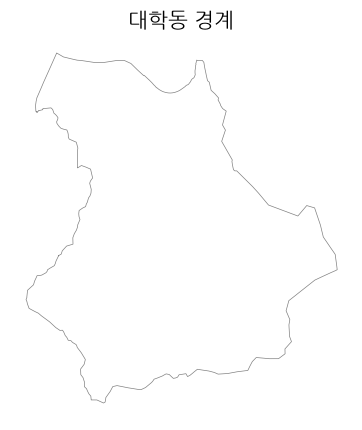

<Figure size 640x480 with 0 Axes>

In [140]:
# 대학동 경계만 추출
daehak_gdf = dong_seoul_4326[
    dong_seoul_4326['ADM_NM'] == '대학동'
].copy()

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1)

daehak_gdf.plot(
    ax=ax,
    color='white',
    edgecolor='grey',
    linewidth=0.5
)

plt.title('대학동 경계', fontsize=15)
plt.grid(False)
plt.axis(False)
plt.show()
plt.savefig('image/1_8.png')


In [141]:
# overlay를 통해 대학동 지역의 아파트 매매건만 추출
apt_daehak = gpd.overlay(seoul_apt_price_2026_gdf, daehak_gdf, how='intersection')     
apt_daehak

,RCPT_YR,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,LOTNO_SE_NM,MNO,SNO,BLDG_NM,...,OPBIZ_RESTAGNT_SGG_NM,LAT,LON,PRICE_PER_SQM,PRICE_PER_PYEONG,BASE_DATE,ADM_CD,ADM_NM,centroid,geometry
0,2026,11620,관악구,10200,신림동,1,대지,1706,0,금호2,...,서울 관악구,37.468250,126.944283,1055.700000,3489.900000,20250630,11210730,대학동,POINT (126.94852 37.45291),POINT (126.94428 37.46825)
1,2026,11620,관악구,10200,신림동,1,대지,1703,1,LIG대학마을(건영아파트3차),...,서울 관악구,37.466846,126.942587,837.100000,2767.200000,20250630,11210730,대학동,POINT (126.94852 37.45291),POINT (126.94259 37.46685)
2,2026,11620,관악구,10200,신림동,1,대지,1703,1,LIG대학마을(건영아파트3차),...,서울 관악구,37.466846,126.942587,1061.100000,3507.800000,20250630,11210730,대학동,POINT (126.94852 37.45291),POINT (126.94259 37.46685)
3,2026,11620,관악구,10200,신림동,1,대지,1559,19,상목에버빌B,...,서울 관악구,37.467907,126.932243,652.400000,2156.500000,20250630,11210730,대학동,POINT (126.94852 37.45291),POINT (126.93224 37.46791)
4,2026,11620,관악구,10200,신림동,1,대지,255,189,현대,...,서울 관악구,37.463742,126.937211,617.400000,2041.100000,20250630,11210730,대학동,POINT (126.94852 37.45291),POINT (126.93721 37.46374)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2026,11620,관악구,10200,신림동,1,대지,1703,1,LIG대학마을(건영아파트3차),...,서울 관악구,37.466846,126.942587,951.400000,3145.200000,20250630,11210730,대학동,POINT (126.94852 37.45291),POINT (126.94259 37.46685)
71,2026,11620,관악구,10200,신림동,1,대지,1703,1,LIG대학마을(건영아파트3차),...,서울 관악구,37.466846,126.942587,911.900000,3014.400000,20250630,11210730,대학동,POINT (126.94852 37.45291),POINT (126.94259 37.46685)
72,2026,11620,관악구,10200,신림동,1,대지,1703,1,LIG대학마을(건영아파트3차),...,서울 관악구,37.466846,126.942587,882.900000,2918.500000,20250630,11210730,대학동,POINT (126.94852 37.45291),POINT (126.94259 37.46685)
73,2026,11620,관악구,10200,신림동,1,대지,1703,1,LIG대학마을(건영아파트3차),...,서울 관악구,37.466846,126.942587,916.800000,3030.800000,20250630,11210730,대학동,POINT (126.94852 37.45291),POINT (126.94259 37.46685)


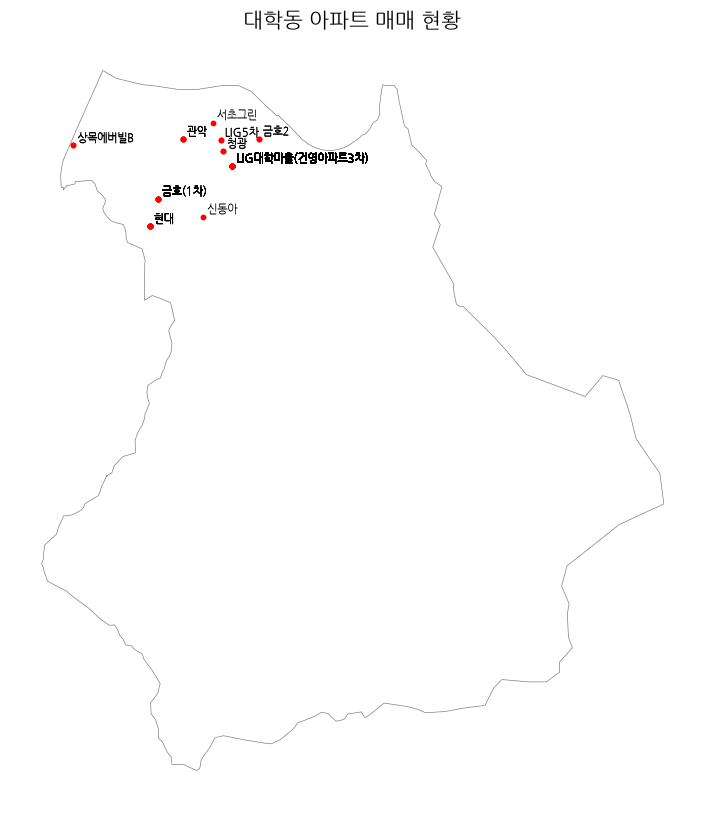

<Figure size 640x480 with 0 Axes>

In [143]:
# 대학동 경계 내 아파트 매매 현황 시각화

fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(1,1,1)
# dong_seoul_4326.plot(ax = ax,  color = 'white', edgecolor='grey', linewidth=0.5)
daehak_gdf.plot(ax = ax,  color = 'white', edgecolor='grey', linewidth=0.5)
apt_daehak.plot(ax=ax,markersize=10, color='red')

# 아파트 이름(BLDG_NM) 레이블 추가
for x, y, name in zip(apt_daehak.geometry.x, apt_daehak.geometry.y, apt_daehak['BLDG_NM']):
    ax.annotate(name, xy=(x, y), xytext=(3, 3), textcoords='offset points', fontsize=8)

plt.title('대학동 아파트 매매 현황', fontsize = 15)
plt.grid(False) 
plt.axis(False)
plt.show()
plt.savefig('image/1_9.png')

### sjoin 연산

sjoin 연산은 GeoDataFrame들의 도형(geometry)을 겹쳐 공간적으로 중첩되는 경우, 속성을 추가해주는 연산입니다.\
예를 들어 아파트 위치가 담긴 GeoDataFrame에 행정동 GeoDataFrame을 지정한 sjoin 연산을 수행할 경우, 아파트 위치에 행정동 정보를 추가할 수 있습니다.

In [144]:
seoul_apt_price_2026_gdf

,RCPT_YR,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,LOTNO_SE_NM,MNO,SNO,BLDG_NM,...,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE,OPBIZ_RESTAGNT_SGG_NM,LAT,LON,PRICE_PER_SQM,PRICE_PER_PYEONG,geometry
0,2026,11530,구로구,11000,온수동,1,대지,154,0,리치안풍산,...,NaN,2009,아파트,중개거래,서울 구로구,37.495866,126.817576,553.000000,1828.100000,POINT (126.81758 37.49587)
1,2026,11260,중랑구,10500,망우동,1,대지,479,0,한일써너스빌리젠시1단지(101동),...,NaN,2008,아파트,중개거래,서울 중랑구,37.597335,127.093478,1044.400000,3452.500000,POINT (127.09348 37.59734)
2,2026,11740,강동구,10900,천호동,1,대지,19,1,우성,...,NaN,1985,아파트,직거래,NaN,37.549768,127.138816,1298.700000,4293.300000,POINT (127.13882 37.54977)
3,2026,11305,강북구,10100,미아동,1,대지,194,2,엘리프미아역1단지,...,NaN,0,아파트,중개거래,서울 강북구,37.629276,127.025459,1400.100000,4628.300000,POINT (127.02546 37.62928)
4,2026,11650,서초구,10100,방배동,1,대지,866,20,방배대우디오빌,...,NaN,2005,아파트,중개거래,서울 동작구,37.486044,126.984201,1006.800000,3328.100000,POINT (126.9842 37.48604)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49954,2026,11470,양천구,10300,신월동,1,대지,1026,0,양천벽산블루밍1단지,...,NaN,2006,아파트,중개거래,서울 양천구,37.524360,126.839446,1046.800000,3460.600000,POINT (126.83945 37.52436)
49955,2026,11380,은평구,10600,대조동,1,대지,9,19,모아아파트(103동),...,NaN,2015,아파트,중개거래,서울 은평구,37.610228,126.927766,980.900000,3242.800000,POINT (126.92777 37.61023)
49956,2026,11680,강남구,11500,수서동,1,대지,746,0,까치마을,...,20260309.000000,1993,아파트,중개거래,서울 강남구,37.484734,127.087618,4094.100000,13534.100000,POINT (127.08762 37.48473)
49957,2026,11260,중랑구,10600,신내동,1,대지,397,0,동성1,...,NaN,1993,아파트,중개거래,서울 중랑구,37.609116,127.097679,830.000000,2743.700000,POINT (127.09768 37.60912)


In [145]:
dong_seoul_4326

,BASE_DATE,ADM_CD,ADM_NM,geometry,centroid
0,20250630,11010530,사직동,"POLYGON ((126.97399 37.57823, 126.974 37.57809...",POINT (126.97038 37.57389)
1,20250630,11010540,삼청동,"POLYGON ((126.97714 37.59768, 126.9773 37.5976...",POINT (126.98121 37.58836)
2,20250630,11010550,부암동,"POLYGON ((126.96173 37.60714, 126.96182 37.607...",POINT (126.96354 37.59696)
3,20250630,11010560,평창동,"POLYGON ((126.97508 37.63118, 126.97488 37.630...",POINT (126.96813 37.61569)
4,20250630,11010570,무악동,"POLYGON ((126.95975 37.58001, 126.96006 37.579...",POINT (126.95859 37.57711)
...,...,...,...,...,...
421,20250630,11250730,천호2동,"POLYGON ((127.11633 37.55005, 127.11642 37.550...",POINT (127.12201 37.54499)
422,20250630,11250740,길동,"POLYGON ((127.14844 37.54544, 127.14843 37.545...",POINT (127.14597 37.5397)
423,20250630,11250750,강일동,"POLYGON ((127.17669 37.57907, 127.17662 37.579...",POINT (127.17336 37.56894)
424,20250630,11250760,상일1동,"POLYGON ((127.17387 37.54591, 127.1739 37.5457...",POINT (127.16479 37.55064)


In [146]:
# sjoin 연산을 통해 두 레이어의 위치 관계에 따라 속성을 결합시킬 수 있습니다.
# 아파트 매매건 마다 행정동 속성을 결합시키기 위해 sjoin 연산을 수행합니다.
apt_price_sjoin = gpd.sjoin(seoul_apt_price_2026_gdf, dong_seoul_4326, how='inner')    #좌측 : 원본 GDF   우측 : 공간에 따라 속성을 결합할 GDF
apt_price_sjoin

,RCPT_YR,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,LOTNO_SE_NM,MNO,SNO,BLDG_NM,...,LAT,LON,PRICE_PER_SQM,PRICE_PER_PYEONG,geometry,index_right,BASE_DATE,ADM_CD,ADM_NM,centroid
0,2026,11530,구로구,11000,온수동,1,대지,154,0,리치안풍산,...,37.495866,126.817576,553.000000,1828.100000,POINT (126.81758 37.49587),270,20250630,11170690,수궁동,POINT (126.82602 37.49844)
1,2026,11260,중랑구,10500,망우동,1,대지,479,0,한일써너스빌리젠시1단지(101동),...,37.597335,127.093478,1044.400000,3452.500000,POINT (127.09348 37.59734),109,20250630,11070730,망우본동,POINT (127.10744 37.60214)
2,2026,11740,강동구,10900,천호동,1,대지,19,1,우성,...,37.549768,127.138816,1298.700000,4293.300000,POINT (127.13882 37.54977),413,20250630,11250610,천호1동,POINT (127.13855 37.54633)
3,2026,11305,강북구,10100,미아동,1,대지,194,2,엘리프미아역1단지,...,37.629276,127.025459,1400.100000,4628.300000,POINT (127.02546 37.62928),137,20250630,11090700,미아동,POINT (127.02639 37.62864)
4,2026,11650,서초구,10100,방배동,1,대지,866,20,방배대우디오빌,...,37.486044,126.984201,1006.800000,3328.100000,POINT (126.9842 37.48604),354,20250630,11220650,방배4동,POINT (126.99098 37.48983)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49954,2026,11470,양천구,10300,신월동,1,대지,1026,0,양천벽산블루밍1단지,...,37.524360,126.839446,1046.800000,3460.600000,POINT (126.83945 37.52436),229,20250630,11150600,신월4동,POINT (126.83985 37.52216)
49955,2026,11380,은평구,10600,대조동,1,대지,9,19,모아아파트(103동),...,37.610228,126.927766,980.900000,3242.800000,POINT (126.92777 37.61023),181,20250630,11120580,대조동,POINT (126.92315 37.61226)
49956,2026,11680,강남구,11500,수서동,1,대지,746,0,까치마을,...,37.484734,127.087618,4094.100000,13534.100000,POINT (127.08762 37.48473),372,20250630,11230720,일원본동,POINT (127.08455 37.48231)
49957,2026,11260,중랑구,10600,신내동,1,대지,397,0,동성1,...,37.609116,127.097679,830.000000,2743.700000,POINT (127.09768 37.60912),105,20250630,11070690,신내1동,POINT (127.10404 37.61316)


In [147]:
# 매매건 하나가 누락되었음. 행정동 경계 밖으로 나간 아파트 매매건이 존재함. (sjoin 연산은 좌표가 폴리곤 안에 있는 경우만 결합) 
apt_price_sjoin.count()

RCPT_YR                  49958
CGG_CD                   49958
CGG_NM                   49958
STDG_CD                  49958
STDG_NM                  49958
LOTNO_SE                 49958
LOTNO_SE_NM              49958
MNO                      49958
SNO                      49958
BLDG_NM                  49958
CTRT_DAY                 49958
THING_AMT                49958
ARCH_AREA                49958
LAND_AREA                49958
FLR                      49958
RGHT_SE                    694
RTRCN_DAY                 1380
ARCH_YR                  49958
BLDG_USG                 49958
DCLR_SE                  49958
OPBIZ_RESTAGNT_SGG_NM    47560
LAT                      49958
LON                      49958
PRICE_PER_SQM            49958
PRICE_PER_PYEONG         49958
geometry                 49958
index_right              49958
BASE_DATE                49958
ADM_CD                   49958
ADM_NM                   49958
centroid                 49958
dtype: int64

In [148]:
# 행정동별 아파트 매매건 수와 평균 매매가를 집계합니다.
# 426개 행정동 중 422개 행정동만 아파트 매매건이 존재함. 나머지 4개 행정동은 아파트 매매건이 없음.
dong_apt_price_summary = apt_price_sjoin.groupby(['ADM_CD','ADM_NM']).agg({'PRICE_PER_PYEONG': ['count', 'mean']}).reset_index()
dong_apt_price_summary.columns = ['ADM_CD', 'ADM_NM', 'APT_COUNT', 'APT_PRICE_MEAN']
dong_apt_price_summary.sort_values('APT_PRICE_MEAN', ascending=False)

,ADM_CD,ADM_NM,APT_COUNT,APT_PRICE_MEAN
343,11220580,반포2동,90,21035.621111
341,11220560,반포본동,6,20075.100000
372,11230770,압구정동,97,16947.530928
354,11230510,신사동,54,16786.696296
344,11220590,반포3동,98,16380.053061
...,...,...,...,...
240,11160550,화곡본동,32,2007.509375
241,11160570,화곡2동,13,2004.830769
151,11100640,도봉1동,26,1964.119231
144,11100560,방학2동,3,1882.900000


In [149]:
# 행정동별 아파트 매매건 수와 평균 매매가를 행정동 경계 GeoDataFrame에 결합합니다.
# 두개 테이블에 Key를 제외한 공통 컬럼(ADM_NM)이 존재해서, ADM_NM_x, ADM_NM_y로 구분해줍니다.
dong_seoul_4326_apt_price=pd.merge(dong_seoul_4326, dong_apt_price_summary, on=['ADM_CD'], how='left')
dong_seoul_4326_apt_price

,BASE_DATE,ADM_CD,ADM_NM_x,geometry,centroid,ADM_NM_y,APT_COUNT,APT_PRICE_MEAN
0,20250630,11010530,사직동,"POLYGON ((126.97399 37.57823, 126.974 37.57809...",POINT (126.97038 37.57389),사직동,31.000000,6781.045161
1,20250630,11010540,삼청동,"POLYGON ((126.97714 37.59768, 126.9773 37.5976...",POINT (126.98121 37.58836),NaN,NaN,NaN
2,20250630,11010550,부암동,"POLYGON ((126.96173 37.60714, 126.96182 37.607...",POINT (126.96354 37.59696),부암동,2.000000,2391.500000
3,20250630,11010560,평창동,"POLYGON ((126.97508 37.63118, 126.97488 37.630...",POINT (126.96813 37.61569),평창동,46.000000,3340.878261
4,20250630,11010570,무악동,"POLYGON ((126.95975 37.58001, 126.96006 37.579...",POINT (126.95859 37.57711),무악동,51.000000,5873.437255
...,...,...,...,...,...,...,...,...
421,20250630,11250730,천호2동,"POLYGON ((127.11633 37.55005, 127.11642 37.550...",POINT (127.12201 37.54499),천호2동,94.000000,3978.178723
422,20250630,11250740,길동,"POLYGON ((127.14844 37.54544, 127.14843 37.545...",POINT (127.14597 37.5397),길동,299.000000,4287.354849
423,20250630,11250750,강일동,"POLYGON ((127.17669 37.57907, 127.17662 37.579...",POINT (127.17336 37.56894),강일동,149.000000,5672.460403
424,20250630,11250760,상일1동,"POLYGON ((127.17387 37.54591, 127.1739 37.5457...",POINT (127.16479 37.55064),상일1동,181.000000,7869.587293


In [150]:
dong_seoul_4326_apt_price.count()

BASE_DATE         426
ADM_CD            426
ADM_NM_x          426
geometry          426
centroid          426
ADM_NM_y          422
APT_COUNT         422
APT_PRICE_MEAN    422
dtype: int64

참고로 색을 변화시키는 기준 역시 구분하는 방법과 갯수를 정의할 수 있으며, 각각 `plot()` 명령어의 `scheme` 인자와 `k`인자에 할당하여 정의할 수 있습니다.

*구분방법 : scheme 인자*
- `equalinterval` :  동일한 간격으로 구분
- `quantiles` :  4분위수를 구하여 구분
- `fisherjenks` : 분류한 클래스 내 분산을 최소화, 클래스 간 분산을 최대화하여 구분

*구분개수 : k 인자*

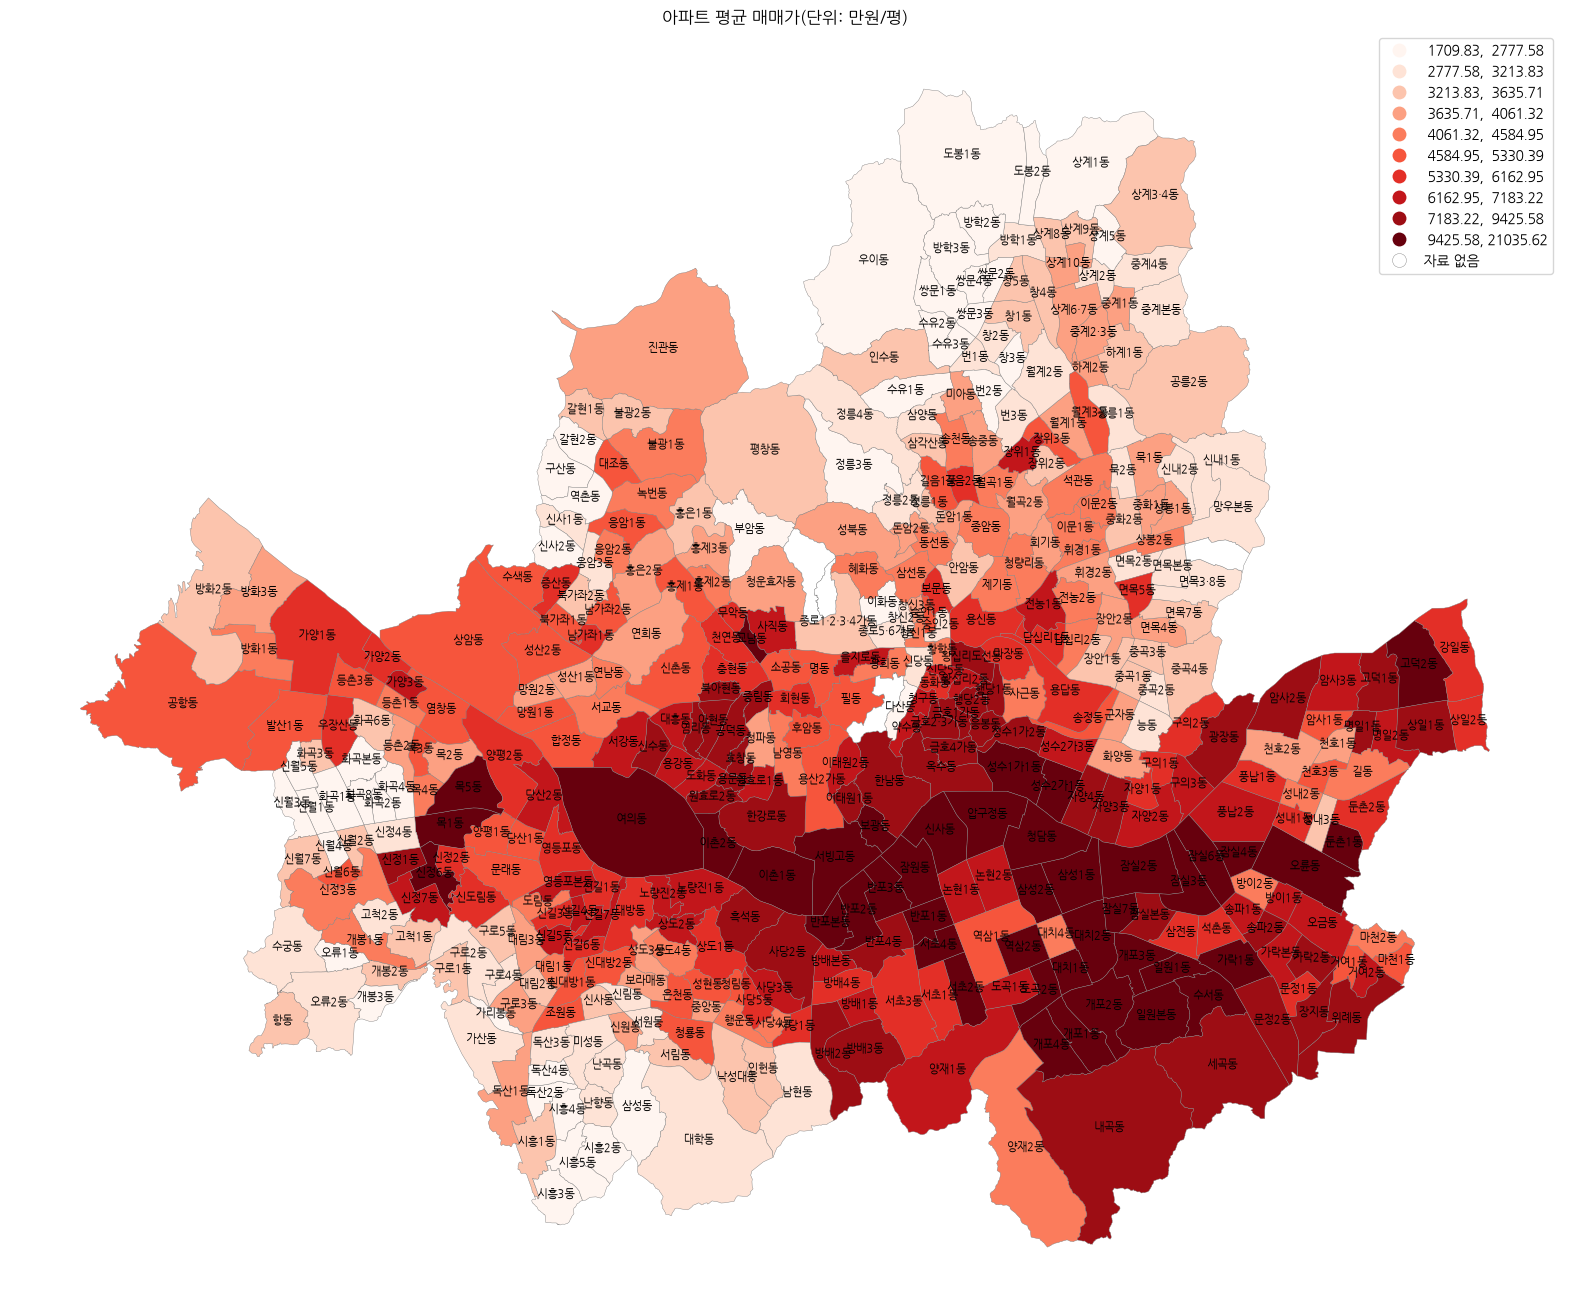

<Figure size 640x480 with 0 Axes>

In [152]:
# 행정동별 아파트 평균 매매가를 시각화합니다. (단위: 만원/평)
fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(1,1,1)

ax.set_title("아파트 평균 매매가(단위: 만원/평)")
ax.set_axis_off()
dong_seoul_4326_apt_price.plot(
    ax=ax,
    column='APT_PRICE_MEAN',
    legend=True,
    edgecolor='grey', 
    linewidth=0.3,
    cmap='Reds',
    scheme='quantiles', 
    k=10,
    missing_kwds={'color': 'white', 'label': '자료 없음'}
)

# 행정동 이름(ADM_NM_y) 레이블 추가
for _, row in dong_seoul_4326_apt_price.iterrows():
    if pd.notna(row['ADM_NM_y']):
        centroid = row['geometry'].centroid
        ax.annotate(row['ADM_NM_y'], xy=(centroid.x, centroid.y), ha='center', fontsize=8)


plt.grid(False)      
plt.axis(False)     
plt.show()
plt.savefig('image/1_10.png')